In [1]:
import glob

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
location_dict = {
    'Augusta': {'lat': -34.25, 'lon': 115.1},
    'Eighty Mile Beach': {'lat': -19.4, 'lon': 121.45},
    'Fitzroy River': {'lat': -18, 'lon': 123.85}
}

## AGCD

In [3]:
agcd_files = sorted(glob.glob('/g/data/xv83/agcd-csiro/precip/daily/precip-total_AGCD-CSIRO_r005_*_daily.nc'))

In [4]:
ds_agcd = xr.open_mfdataset(agcd_files[60:-2])

/jobfs/167529757.gadi-pbs/ipykernel_62626/4263086412.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_agcd = xr.open_mfdataset(agcd_files[60:-2])


In [6]:
ds_agcd = ds_agcd.sel(location_dict['Augusta'], method='nearest', drop=True)

In [8]:
ds_agcd = ds_agcd.compute()

In [10]:
ds_agcd.to_netcdf('/g/data/xv83/dbi599/wa/precip-total_AGCD-CSIRO_r005-augusta_1960-2022_daily.nc')

In [17]:
da_agcd = ds_agcd['precip']

In [18]:
len(da_agcd)

23011

## Model data

In [11]:
def get_infiles(rcm, gcm, bc):
    """Get infiles"""

    assert bc in ['QME', 'MRNBC', 'raw']

    if bc == 'raw':
        activity = 'DD'
        var = 'pr'
        version = 'v1-r1'
    else:
        activity = 'bias-adjusted-output'
        var = 'prAdjust'
        version = f'v1-r1-ACS-{bc}-AGCDv1-1960-2022'

    hist_files = sorted(glob.glob(f'/g/data/kj66/CORDEX/output-CMIP6/{activity}/AUST-05i/*/{gcm}/historical/*/{rcm}/{version}/day/{var}/v20241216/*.nc'))
    ssp_files = sorted(glob.glob(f'/g/data/kj66/CORDEX/output-CMIP6/{activity}/AUST-05i/*/{gcm}/ssp370/*/{rcm}/{version}/day/{var}/v20241216/*.nc'))
    file_list = hist_files + ssp_files
    
    return file_list, var

In [24]:
def point_data(rcm, gcm, bc, loc):
    """Exrtract 1960-2022 point data."""

    file_list, var = get_infiles(rcm, gcm, bc)
    ds = xr.open_mfdataset(file_list)
    ds_location = ds.sel(location_dict[loc], method='nearest', drop=True)
    ds_location_time = ds_location.sel(time=slice('1960-01-01', '2022-12-31'))
    ds_location_time = ds_location_time.compute()

    return ds_location_time

In [25]:
rcm = 'BARPA-R'
gcm = 'NorESM2-MM'

In [26]:
ds_raw = point_data(rcm, gcm, 'raw', 'Augusta')
da_raw = ds_raw['pr']

/jobfs/167529757.gadi-pbs/ipykernel_62626/231149236.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_list)


In [29]:
outfile = '/g/data/xv83/dbi599/wa/pr_AUST-05i-augusta_NorESM2-M_ssp370_r1i1p1f1_BOM_BARPA-R_v1-r1_day_1960-2022.nc'
ds_raw.to_netcdf(outfile)

In [65]:
ds_qme = point_data(rcm, gcm, 'QME', 'Augusta')
da_qme = ds_qme['prAdjust']

/jobfs/166587203.gadi-pbs/ipykernel_1373486/2918729659.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_list)


In [66]:
ds_mrnbc = point_data(rcm, gcm, 'MRNBC', 'Augusta')
da_mrnbc = ds_mrnbc['prAdjust']

/jobfs/166587203.gadi-pbs/ipykernel_1373486/2918729659.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_list)


## Plot

In [52]:
bin_edges = np.arange(0, 51, 2)
bin_centres = np.arange(1, 50, 2)

In [53]:
freq_agcd, edges = np.histogram(da_agcd.values, bin_edges)
prob_agcd = (freq_agcd / freq_agcd.sum()) * 100

In [67]:
freq_qme, edges = np.histogram(da_qme.values, bin_edges)
prob_qme = (freq_qme / freq_qme.sum()) * 100

In [68]:
freq_mrnbc, edges = np.histogram(da_mrnbc.values, bin_edges)
prob_mrnbc = (freq_mrnbc / freq_mrnbc.sum()) * 100

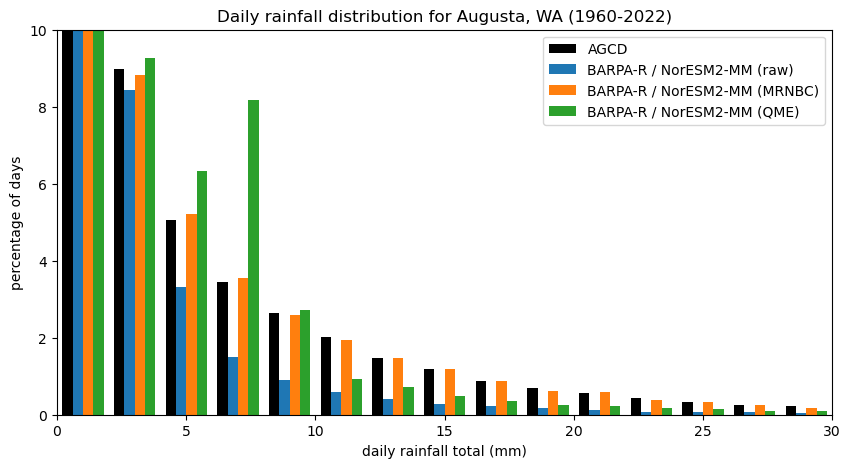

In [72]:
fig, ax = plt.subplots(1, figsize=[10, 5])

ax.bar(bin_centres - 0.6, prob_agcd, width=0.4, label='AGCD', color='black')
ax.bar(bin_centres - 0.2, prob_raw, width=0.4, label='BARPA-R / NorESM2-MM (raw)', color='tab:blue')
ax.bar(bin_centres + 0.2, prob_mrnbc, width=0.4, label='BARPA-R / NorESM2-MM (MRNBC)', color='tab:orange')
ax.bar(bin_centres + 0.6, prob_qme, width=0.4, label='BARPA-R / NorESM2-MM (QME)', color='tab:green')
ax.legend()
ax.set_ylim(0, 10)
ax.set_xlim(0, 30)
ax.set_ylabel('percentage of days')
ax.set_xlabel('daily rainfall total (mm)')
ax.set_title('Daily rainfall distribution for Augusta, WA (1960-2022)')
plt.show()